# 节点自由分配的规划—可调度域

四节点五走廊网架，三个负荷节点为 1、2、3。各节点负荷非负、自由分配，不设置分区基准或增长比例。
网架、设备、成本均在 `Network/four_bus_five_corridor.py`。

预算 $B$ 下的规划域定义为 $\mathcal D(B)=\bigcup_{x:c^Tx\le B}\mathcal F_x$。
每个建设方案单独认证可调度域，不同方案取非凸并集；蓝色区域中的每一点至少有一个预算内方案可行。


**1 · 载入模块与网架。** 重跑此块重置实验；切换网架时修改导入。`power` 的顺序对应 `network.load_nodes`。


In [1]:
from itertools import combinations, product
from math import gcd
from pathlib import Path
from time import sleep

import numpy as np
from gurobipy import GRB
from IPython.display import clear_output

from Network.four_bus_five_corridor import network
from model import MP1, MP2, SP, TOL, add_cut
from region import simplex, update_outer, add_certificate, ResidualSearch
from plot import show_benders, plot_frontier, plot_regions
from replay import Replay
from planning import MP1SP, MP2SP, Planning

mp1sp = mp2sp = cooperative = None
studies = {}
budget_replay = None


**2 · MP1SP：给定节点负荷，求最低建设费用。**

固定 $p=(p_1,p_2,p_3)$，SP 检查该建设方案下的电气可行性。
左图为费用下界，右图为电气违反量。`STEPS` 是本次最多推进轮数，重复运行可续算，完成后自动停止。


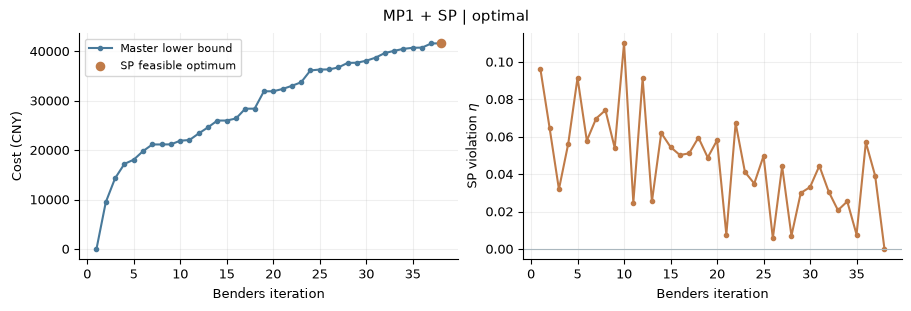

{'status': '最优',
 'cost': 41600.0,
 'power': array([40., 35., 25.]),
 'total': 100.0,
 'x': array([-0., -0.,  1., -0.,  0.,  1., -0., -0.,  1., -0., -0., -0.,  0.,
        -0.,  0.])}

In [2]:
POWER = np.array([40., 35., 25.])  # 节点 1、2、3 的负荷。
STEPS = 1000  # 1：只推进一轮；20：最多20轮；完成后自动停止。
PAUSE = 0  # 演示不暂停；改成1即可逐轮观察。

if mp1sp is None or not np.array_equal(mp1sp.target, POWER):
    mp1sp = MP1SP(POWER)
mp1sp.run(STEPS, PAUSE)


**3 · MP2SP：给定预算，求最大总负荷。**

允许各节点自由分配负荷，最大化 $\sum_i p_i$。`BUDGET=np.inf` 只取消预算限制。
本块与 MP1SP 独立求解，保留 Benders 过程图。


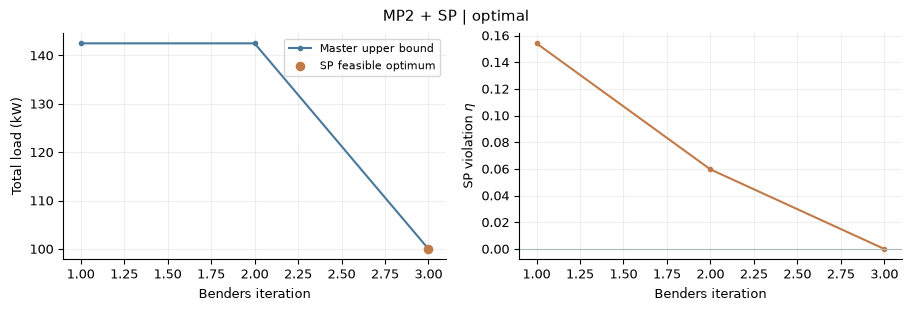

{'status': '最优',
 'cost': 14300.0,
 'power': array([100.,   0.,   0.]),
 'total': 100.0,
 'x': array([0., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])}

In [3]:
BUDGET = 30000.
STEPS = 1000
PAUSE = 0

if mp2sp is None or mp2sp.target != BUDGET:
    mp2sp = MP2SP(BUDGET)
mp2sp.run(STEPS, PAUSE)


**4 · 四档预算的协同求解与完整切割回放。**

分别求解 20,000、40,000、60,000 元和无限预算。每档沿用 MP2SP → 总量 MP1SP 的费用前沿流程，
随后按需扣除各方案的认证并集，将未覆盖部分分成局部凸块，优先处理贡献较大的凸块。

块内先检查未覆盖顶点，再检查与已认证域相交产生的边界顶点。同一方案的可行顶点可以认证整块凸域；
不可行点产生有效割，收缩候选域后重新安排搜索。不同方案只取并集，不跨方案取凸包。
队列中所有剩余块均已被覆盖或有效割删除时，才在几何容差 $10^{-7}$ kW 内宣布完整认证。
达到 `STEPS` 上限仅暂停；`STEPS` 对每档预算分别生效，重跑本块续算。

默认回放四档预算的最终区域；选择“完整切割过程”或“仅新增割”可查看某档预算的全部求解历史。
四档使用相同坐标尺度并保持旋转视角。当前三维绘图对应三个自由负荷节点，完整认证仍枚举小网架的建设方案。


In [4]:
BUDGETS = (20000., 40000., 60000., np.inf)
STEPS = 10000  # 每档预算最多推进这些轮次；1：单步；20：分批；完成后自动停止。
PAUSE = 0  # 改成1可在每两轮之间暂停1秒。

for budget in BUDGETS:
    if budget not in studies:
        studies[budget] = Planning(budget)
    studies[budget].run(STEPS, PAUSE, show=False)
    print(f"预算 {budget:,.0f} 元：", studies[budget].result)

cooperative = studies[BUDGETS[-1]]
processes = [studies[budget] for budget in BUDGETS]
if budget_replay is None or budget_replay.processes != processes:
    budget_replay = Replay(processes)
budget_replay.show(Path("results") / f"{network.name}.html")


预算 20,000 元： {'status': '完整规划—可调度域已认证', 'iterations': 38, 'cuts': 9, 'max_total': 100.0, 'frontier': [(35.0, 0.0), (65.0, 9460.0), (100.0, 14300.0)]}


预算 40,000 元： {'status': '完整规划—可调度域已认证', 'iterations': 107, 'cuts': 35, 'max_total': 135.0, 'frontier': [(35.0, 0.0), (65.0, 9460.0), (100.0, 14300.0), (135.0, 33000.0)]}


预算 60,000 元： {'status': '完整规划—可调度域已认证', 'iterations': 114, 'cuts': 34, 'max_total': 142.5, 'frontier': [(35.0, 0.0), (65.0, 9460.0), (100.0, 14300.0), (135.0, 33000.0), (142.5, 40700.0)]}


预算 inf 元： {'status': '完整规划—可调度域已认证', 'iterations': 60, 'cuts': 28, 'max_total': 142.5, 'frontier': [(35.0, 0.0), (65.0, 9460.0), (100.0, 14300.0), (135.0, 33000.0), (142.5, 40700.0)]}
